<a href="https://colab.research.google.com/github/Madadi1991/DjangoPython/blob/main/Depp_NN_Madadi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [7]:
data =pd.read_csv('/content/Airline_Delay_Cause.csv')
data.shape

(318017, 21)

In [8]:
data.dropna(inplace=True)

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 317261 entries, 0 to 318016
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   year                 317261 non-null  int64  
 1   month                317261 non-null  int64  
 2   carrier              317261 non-null  object 
 3   carrier_name         317261 non-null  object 
 4   airport              317261 non-null  object 
 5   airport_name         317261 non-null  object 
 6   arr_flights          317261 non-null  float64
 7   arr_del15            317261 non-null  float64
 8   carrier_ct           317261 non-null  float64
 9   weather_ct           317261 non-null  float64
 10  nas_ct               317261 non-null  float64
 11  security_ct          317261 non-null  float64
 12  late_aircraft_ct     317261 non-null  float64
 13  arr_cancelled        317261 non-null  float64
 14  arr_diverted         317261 non-null  float64
 15  arr_delay            3

In [10]:
data['weather_delay'].min(),data['weather_delay'].max()

(0.0, 57707.0)

In [11]:
data['wDCase']=data['weather_delay'].apply(lambda x: 1 if x>100 else 0)

In [12]:
data['wDCase'].value_counts()

,count
wDCase,
0,215111
1,102150


In [13]:
X = data.drop(['wDCase'], axis=1)
X = pd.get_dummies(X, columns=['carrier', 'carrier_name', 'airport', 'airport_name'], drop_first=True)
y = data['wDCase']

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [15]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((212564, 911), (104697, 911), (212564,), (104697,))

In [16]:
import tensorflow as tf
import keras

In [17]:
KerasModel = keras.models.Sequential([
            # keras.layers.Input(shape=(21)),
            keras.layers.Dense(8,  activation = 'tanh'),
            # keras.layers.Dropout(0.1),
            keras.layers.Dense(128, activation = 'sigmoid'),
            # keras.layers.Dropout(0.3),
            keras.layers.Dense(64, activation = 'tanh'),
            # keras.layers.Dense(32, activation = 'tanh'),
            keras.layers.Dropout(0.2),
            keras.layers.Dense(1, activation = 'sigmoid')
            ])

In [18]:
MyOptimizer = tf.keras.optimizers.AdamW(
    learning_rate=0.001,
    weight_decay=0.004,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-07,
    amsgrad=False,
    clipnorm=None,
    clipvalue=None,
    global_clipnorm=None,
    use_ema=False,
    ema_momentum=0.99,
    ema_overwrite_frequency=None,
    loss_scale_factor=None,
    gradient_accumulation_steps=None,
    name="adamw",
)


In [19]:
KerasModel.compile(
    optimizer=MyOptimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [20]:
history = KerasModel.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    batch_size=10000,
    epochs=100,
    verbose=1,
    callbacks=[keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        mode='auto',
        restore_best_weights=True,
    )],

)

Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 142ms/step - accuracy: 0.7042 - loss: 0.5849 - val_accuracy: 0.7699 - val_loss: 0.4938
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 255ms/step - accuracy: 0.7805 - loss: 0.4652 - val_accuracy: 0.8117 - val_loss: 0.4289
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 243ms/step - accuracy: 0.8247 - loss: 0.3993 - val_accuracy: 0.8647 - val_loss: 0.3413
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 261ms/step - accuracy: 0.9121 - loss: 0.2328 - val_accuracy: 0.9668 - val_loss: 0.1059
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 104ms/step - accuracy: 0.9801 - loss: 0.0698 - val_accuracy: 0.9879 - val_loss: 0.0370
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 111ms/step - accuracy: 0.9863 - loss: 0.0388 - val_accuracy: 0.9930 - val_loss: 0.0261
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 124ms/step - accuracy: 0.9911 - loss: 0.0270 - val_accuracy: 0.9903 - val_loss: 0.0285
Epoch 8/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 135ms/step - accuracy: 0.9940 - loss: 0.0180 - val_accu

In [21]:
print(history.history.keys())
print(KerasModel.summary())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │         7,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,309 (196.52 KB)

 Trainable params: 16,769 (65.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 33,540 (131.02 KB)

None


In [22]:
KerasModel.save('/content/kerasModel.keras')

In [23]:
New_keras_model = keras.models.load_model('/content/kerasModel.keras')

In [24]:
X_test

,year,month,arr_flights,arr_del15,carrier_ct,weather_ct,nas_ct,security_ct,late_aircraft_ct,arr_cancelled,...,"airport_name_Williston, ND: Sloulin Field International","airport_name_Williston, ND: Williston Basin International","airport_name_Wilmington, DE: New Castle","airport_name_Wilmington, NC: Wilmington International","airport_name_Worcester, MA: Worcester Regional","airport_name_Wrangell, AK: Wrangell Airport","airport_name_Yakima, WA: Yakima Air Terminal/McAllister Field","airport_name_Yakutat, AK: Yakutat Airport","airport_name_Youngstown/Warren, OH: Youngstown-Warren Regional","airport_name_Yuma, AZ: Yuma MCAS/Yuma International"
275895,2005,12,816.0,255.0,76.98,9.44,101.32,0.00,67.26,12.0,...,False,False,False,False,False,False,False,False,False,False
119384,2015,4,290.0,67.0,15.80,2.00,32.16,0.00,17.04,5.0,...,False,False,False,False,False,False,False,False,False,False
117327,2015,6,116.0,22.0,6.98,1.58,4.46,0.00,8.99,7.0,...,False,False,False,False,False,False,False,False,False,False
53842,2019,9,175.0,17.0,7.83,1.00,3.35,0.00,4.82,0.0,...,False,False,False,False,False,False,False,False,False,False
153312,2013,1,58.0,6.0,1.71,1.00,3.28,0.00,0.01,5.0,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2294,2022,4,86.0,22.0,3.02,0.00,10.72,0.24,8.02,0.0,...,False,False,False,False,False,False,False,False,False,False
67423,2019,1,1001.0,166.0,55.02,10.50,47.99,0.00,52.49,18.0,...,False,False,False,False,False,False,False,False,False,False
149368,2013,4,52.0,10.0,2.26,0.00,4.50,0.00,3.24,0.0,...,False,False,False,False,False,False,False,False,False,False
100722,2016,10,66.0,7.0,3.29,1.00,1.71,0.00,1.00,0.0,...,False,False,False,False,False,False,False,False,False,False


In [25]:
y_pred = New_keras_model.predict(X_test)

3272/3272 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step


In [26]:
print(y_pred.shape)
print(y_pred[:10])
#

(104697, 1)
[[9.99711096e-01]
 [1.32550267e-04]
 [1.43240029e-02]
 [1.21431236e-04]
 [9.99560535e-01]
 [9.99579012e-01]
 [9.99711096e-01]
 [9.99711096e-01]
 [3.33863437e-01]
 [1.37030365e-04]]


In [27]:
y_test[:10]

,wDCase
275895,1
119384,0
117327,0
53842,0
153312,1
221961,1
160501,1
109140,1
264494,0
151102,0


In [28]:
Modelloss, modelaccuracy = New_keras_model.evaluate(X_test, y_test)
print(Modelloss, modelaccuracy)
#

3272/3272 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9986 - loss: 0.0035
0.00351187726482749 0.998615026473999


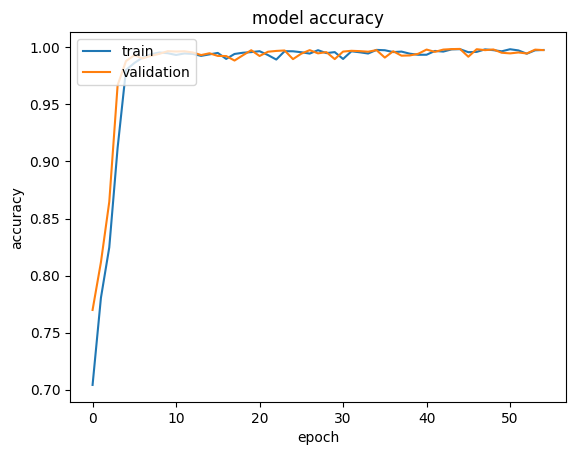

In [30]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()
#

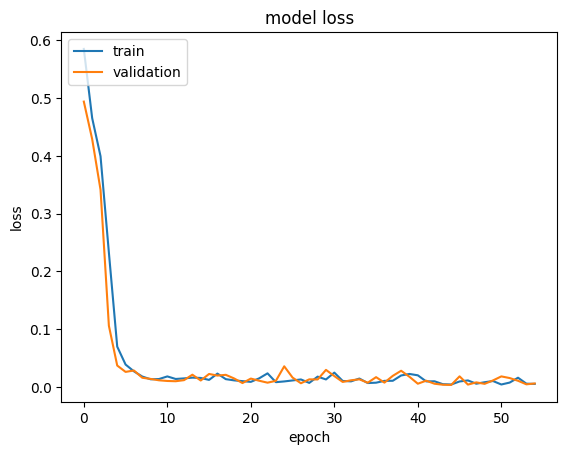

In [31]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

In [33]:
len(y_test), len(y_pred)

(104697, 104697)

In [34]:
y_pred

array([[9.9971110e-01],
       [1.3255027e-04],
       [1.4324003e-02],
       ...,
       [2.6517995e-05],
       [1.2140207e-04],
       [4.0580722e-05]], dtype=float32)

In [37]:
y_pred = [np.round(i) for i in y_pred]
y_pred

[np.float32(1.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(1.0),
 np.float32(1.0),
 np.float32(1.0),
 np.float32(1.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(1.0),
 np.float32(0.0),
 np.float32(1.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(1.0),
 np.float32(0.0),
 np.float32(1.0),
 np.float32(1.0),
 np.float32(0.0),
 np.float32(1.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(1.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(1.0),
 np.float32(1.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(1.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(1.0),
 np.float32(1.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(1.0),
 np.float32(0.0),
 np.float32(1.0),
 np.float32(0.0),
 np.float3

classification report               precision    recall  f1-score   support

           0       1.00      1.00      1.00     70843
           1       1.00      1.00      1.00     33854

    accuracy                           1.00    104697
   macro avg       1.00      1.00      1.00    104697
weighted avg       1.00      1.00      1.00    104697

confusion matrix [[70769    74]
 [   71 33783]]


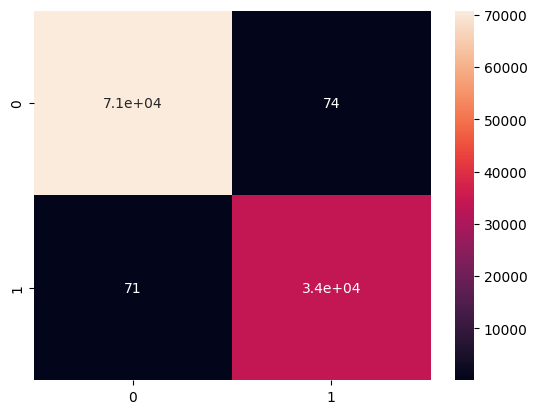

In [40]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
print('classification report',classification_report(y_test, y_pred))
print('confusion matrix',cm)
sns.heatmap(cm, annot=True)
cm = confusion_matrix(y_test, y_pred)